# Stochastic control vs. reinforcement learning

Every method is scored on the same weeks, through the same simulator, under
`docs/experiments/scoring_rule.md`. This notebook reads `results/historical_*.csv`; it trains
nothing and re-scores nothing.

Registered before the results existed: the PPO configuration (`PPO_config.md`), the scoring rule
(`scoring_rule.md`), the baselines (`baselines.md`), the NYISO setup (`nyiso_setup.md`) and the
bootstrap source (`bootstrap_source.md`).

Reproduce with:

    python scripts/train.py --market CISO --source ou --seed 100
    python scripts/eval_historical.py --market CISO --model <model>.zip --name rl_ou_s100
    python scripts/compare_methods.py

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.windows import load_windows

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

MARKETS = [("CISO", "CISO"), ("NYISO", "NYIS")]

def load(code_):
    """Scored weekly results, one row per week per method (see docs/experiments/scoring_rule.md)."""
    t = pd.read_csv(ROOT / "results" / f"historical_{code_}.csv", float_precision="round_trip")
    wide = t.pivot(index="week_idx", columns="method", values="score")
    info = t[t.method == "dp"].sort_values("week_idx").set_index("week_idx")
    return t, wide, info

def stats(s, pf):
    return {"mean weekly score": s.mean(), "value capture": s.sum() / pf.sum(),
            "Sharpe": s.mean() / s.std(ddof=0), "win rate": (s > 0).mean(), "worst week": s.min()}

from IPython.display import Image, display
from src.stats import method_groups, paired_comparison
from src.rl.evaluate import check_validity

ORDER = ["pf", "dp", "schedule", "rl_boot", "rl_ou", "threshold"]
LABEL = {"pf": "perfect foresight", "dp": "DP (stochastic control)", "schedule": "fixed daily schedule",
         "rl_boot": "RL, bootstrap-trained", "rl_ou": "RL, OU-trained", "threshold": "price threshold"}

def grouped(code_):
    """Seed-averaged weekly score per method group."""
    t, wide, info = load(code_)
    groups = {"dp": ["dp"], "pf": ["pf"], **method_groups(t)}
    series = pd.DataFrame({g: wide[cols].mean(axis=1) for g, cols in groups.items()})
    return t, series, info

## Method comparison

In [2]:
for name, c in MARKETS:
    t, s, info = grouped(c)
    tab = pd.DataFrame({LABEL[m]: {**stats(s[m], info.pf_score),
                                   "vs DP": (s[m] - s["dp"]).mean()} for m in ORDER}).T
    print(f"\n{name} — {len(s)} weeks")
    display(tab.style.format({"mean weekly score": "${:,.0f}", "value capture": "{:.1%}",
                              "Sharpe": "{:.2f}", "win rate": "{:.0%}", "worst week": "${:,.0f}",
                              "vs DP": "${:+,.0f}"}))


CISO — 114 weeks


,mean weekly score,value capture,Sharpe,win rate,worst week,vs DP
perfect foresight,"$18,314",100.0%,1.70,100%,"$3,225","$+3,756"
DP (stochastic control),"$14,559",79.5%,1.47,99%,"$-2,195",$+0
fixed daily schedule,"$14,216",77.6%,1.48,99%,$-902,$-343
"RL, bootstrap-trained","$13,643",74.5%,1.46,99%,"$-1,884",$-915
"RL, OU-trained","$13,472",73.6%,1.44,99%,"$-3,004","$-1,086"
price threshold,"$5,240",28.6%,1.21,96%,$0,"$-9,318"



NYISO — 333 weeks


,mean weekly score,value capture,Sharpe,win rate,worst week,vs DP
perfect foresight,"$16,674",100.0%,1.29,100%,"$2,625","$+5,757"
DP (stochastic control),"$10,918",65.5%,1.32,99%,$0,$+0
fixed daily schedule,"$11,279",67.6%,1.22,99%,"$-5,416",$+362
"RL, bootstrap-trained","$8,455",50.7%,1.54,99%,$-324,"$-2,463"
"RL, OU-trained","$9,245",55.4%,1.59,100%,"$-1,058","$-1,673"
price threshold,"$3,424",20.5%,1.07,82%,$0,"$-7,494"


## Paired statistics

Weekly scores are autocorrelated (+0.58 CISO, +0.66 NYISO), so intervals come from a circular block
bootstrap with block length ⌈n^(1/3)⌉ and 10,000 resamples. A coverage study found i.i.d. intervals
hold only 67–69% coverage on this data while claiming 95%; the block bootstrap reaches 87–90%.

The last row of each table compares the two RL agents directly rather than against the DP.

In [3]:
for name, c in MARKETS:
    t, s, _ = grouped(c)
    groups = method_groups(t)
    rows = {}
    for m in ("schedule", "rl_boot", "rl_ou", "threshold"):
        r = paired_comparison(t, groups[m], c)
        rows[LABEL[m]] = {"mean vs DP": r["mean_delta"], "% of DP": r["pct_of_baseline"],
                          "95% CI": f"[{r['ci_low']:+,.0f}, {r['ci_high']:+,.0f}]",
                          "beats DP": r["beats_baseline"], "verdict": r["verdict"]}
    h = paired_comparison(t, groups["rl_boot"], c, baseline=groups["rl_ou"])
    rows["bootstrap vs OU"] = {"mean vs DP": h["mean_delta"], "% of DP": h["pct_of_baseline"],
                               "95% CI": f"[{h['ci_low']:+,.0f}, {h['ci_high']:+,.0f}]",
                               "beats DP": h["beats_baseline"], "verdict": h["verdict"].replace("DP", "OU")}
    print(f"\n{name}")
    display(pd.DataFrame(rows).T.style.format({"mean vs DP": "${:+,.0f}", "% of DP": "{:+.1%}",
                                               "beats DP": "{:.0%}"}))


CISO


,mean vs DP,% of DP,95% CI,beats DP,verdict
fixed daily schedule,$-343,-2.4%,"[-1,082, +407]",42%,inconclusive
"RL, bootstrap-trained",$-915,-6.3%,"[-1,776, -34]",34%,underperforms DP
"RL, OU-trained","$-1,086",-7.5%,"[-1,823, -380]",26%,underperforms DP
price threshold,"$-9,318",-64.0%,"[-11,994, -6,782]",6%,underperforms DP
bootstrap vs OU,$+171,+1.3%,"[-51, +442]",66%,inconclusive



NYISO


,mean vs DP,% of DP,95% CI,beats DP,verdict
fixed daily schedule,$+362,+3.3%,"[-243, +985]",36%,inconclusive
"RL, bootstrap-trained","$-2,463",-22.6%,"[-3,582, -1,519]",29%,underperforms DP
"RL, OU-trained","$-1,673",-15.3%,"[-2,597, -939]",24%,underperforms DP
price threshold,"$-7,494",-68.6%,"[-9,425, -5,839]",4%,underperforms DP
bootstrap vs OU,$-790,-8.5%,"[-1,197, -418]",50%,underperforms OU


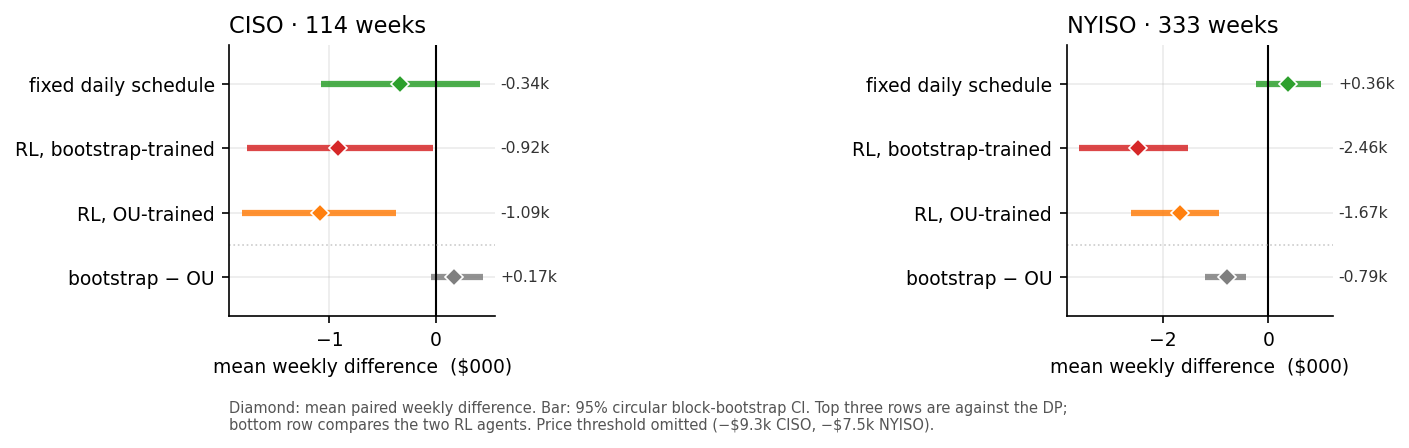

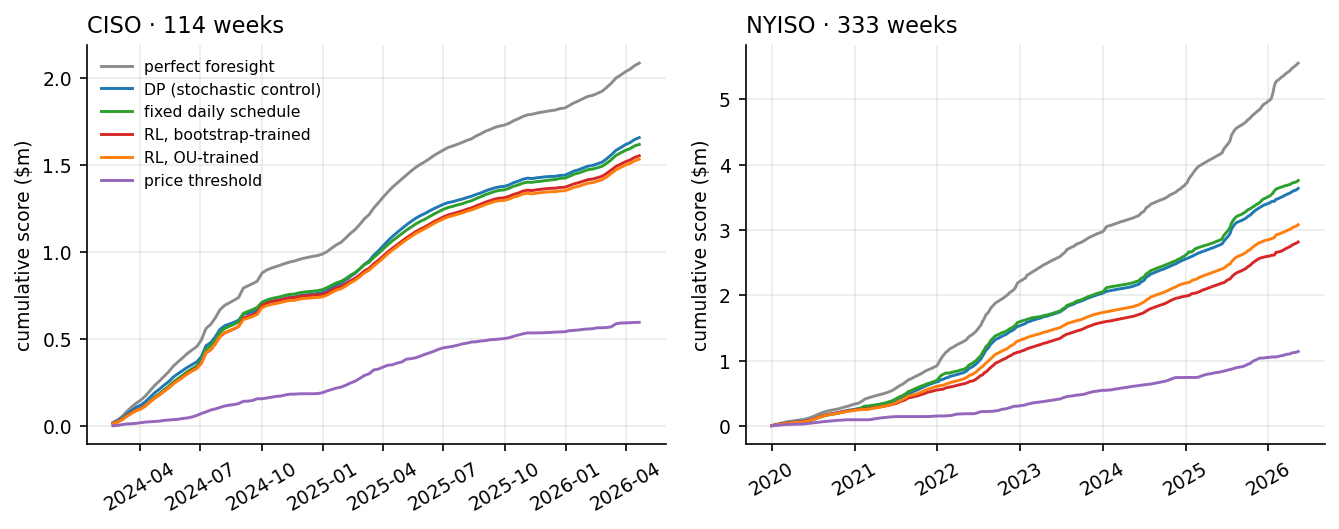

In [4]:
display(Image(filename=str(ROOT / "figures" / "paired_vs_dp.png")))
display(Image(filename=str(ROOT / "figures" / "cumulative_pnl.png")))

## The training distribution mattered more than the algorithm

A first attempt used priors roughly four times wider than reality in log terms, so only about 12%
of training episodes resembled a real week. Performance peaked early and then decayed: the agent
was converging on the optimum of the wrong problem. Matching the priors to the measured
calibrations reversed it.

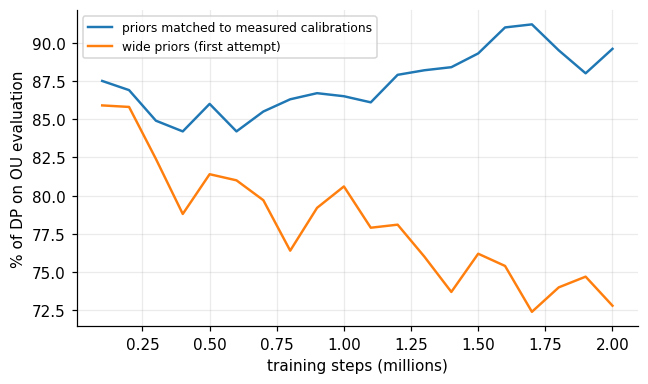

                                         first   max  last
run                                                       
priors matched to measured calibrations   87.5  91.2  89.6
wide priors (first attempt)               85.9  85.9  72.8

source: training console output; event files not retained


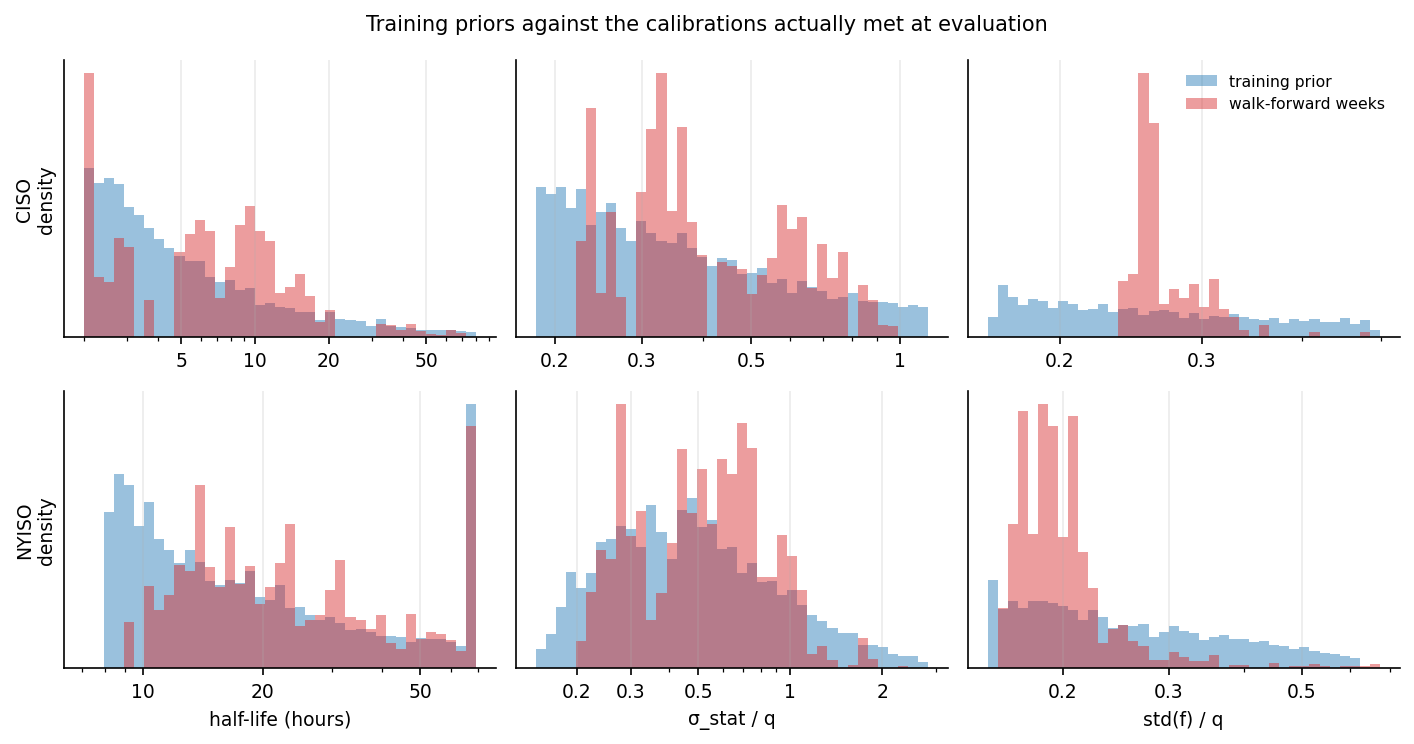

In [5]:
curves = pd.read_csv(ROOT / "results" / "training_curves.csv")
fig, ax = plt.subplots(figsize=(6, 3.6))
for run, g in curves.groupby("run"):
    g = g.sort_values("step")
    ax.plot(g.step / 1e6, g.value, lw=1.6, label=run)
ax.set_xlabel("training steps (millions)"); ax.set_ylabel("% of DP on OU evaluation")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(curves.groupby("run").value.agg(["first", "max", "last"]).round(1).to_string())
print("\nsource:", curves.source.iloc[0])
display(Image(filename=str(ROOT / "figures" / "prior_vs_actual.png")))

## The agents are conservative rather than erratic

In NYISO the RL agents run a higher Sharpe than the DP while earning less, and win almost every
week. They give up upside to avoid bad weeks.

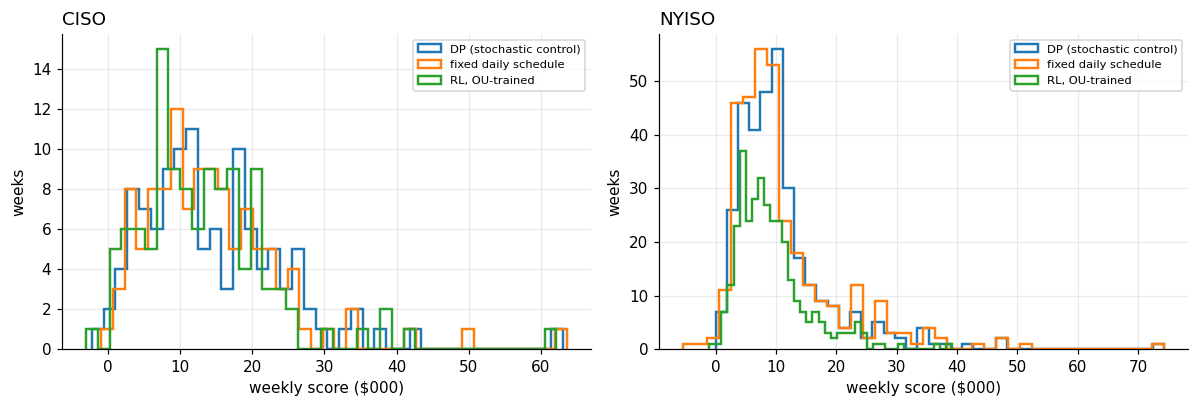

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, c) in zip(axes, MARKETS):
    _, s, _ = grouped(c)
    for m in ("dp", "schedule", "rl_ou"):
        ax.hist(s[m] / 1000, bins=40, histtype="step", lw=1.6, label=LABEL[m])
    ax.set_xlabel("weekly score ($000)"); ax.set_title(name, loc="left"); ax.set_ylabel("weeks")
    ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## When does the controller earn its complexity?

A fixed daily timetable matches the DP on average. The DP's advantage is conditional: it shows up
in weeks with a large realized opportunity and in high-volatility weeks, and it protects the left
tail. In NYISO it gives that back in the largest weeks — the sustained-trend failure the OU model
cannot represent.

In [7]:
for name, c in MARKETS:
    _, s, info = grouped(c)
    d = s["dp"] - s["schedule"]
    print(f"\n{name}: DP − schedule ${d.mean():+,.0f}/week, DP ahead in {(d > 0).mean():.0%} of weeks")
    by_opp = d.groupby(pd.qcut(info.pf_score, 3, labels=["low", "mid", "high"]).values, observed=True).mean()
    by_vol = d.groupby(pd.qcut(info.sigma_stat, 3, labels=["low", "mid", "high"]).values, observed=True).mean()
    print("   by perfect-foresight opportunity: " + " | ".join(f"{k} ${v:+,.0f}" for k, v in by_opp.items()))
    print("   by calibrated volatility:         " + " | ".join(f"{k} ${v:+,.0f}" for k, v in by_vol.items()))
    print(f"   worst week: DP ${s['dp'].min():,.0f} vs schedule ${s['schedule'].min():,.0f}")


CISO: DP − schedule $+343/week, DP ahead in 58% of weeks
   by perfect-foresight opportunity: low $-379 | mid $+145 | high $+1,262
   by calibrated volatility:         low $+373 | mid $+510 | high $+145
   worst week: DP $-2,195 vs schedule $-902

NYISO: DP − schedule $-362/week, DP ahead in 64% of weeks
   by perfect-foresight opportunity: low $+200 | mid $+278 | high $-1,562
   by calibrated volatility:         low $-556 | mid $-1,080 | high $+551
   worst week: DP $0 vs schedule $-5,416


## What the harness guarantees

These checks run in CI-style scripts (`scripts/check_*.py`); the validity rule is re-asserted here
over the delivered results.

In [8]:
import json, glob
for name, c in MARKETS:
    t, _, _ = load(c)
    check_validity(t)            # raises on mask violations or any method beating perfect foresight
    print(f"{name}: {t.week_idx.nunique()} weeks x {t.method.nunique()} methods, "
          f"mask violations {t.mask_violations.max()}, no week beats perfect foresight")

man = [json.load(open(p)) for p in sorted(glob.glob(str(ROOT / "results" / "manifests" / "*.json")))]
print(f"\n{len(man)} training runs | all finished at 2M steps from clean code: "
      f"{all(m['status'] == 'finished' and m['total_timesteps'] == 2_000_000 and not m['git_dirty'] for m in man)}")
print("commits:", sorted({m["git_commit"][:8] for m in man}),
      "| versions:", man[0]["versions"])

CISO: 114 weeks x 14 methods, mask violations 0, no week beats perfect foresight
NYISO: 333 weeks x 14 methods, mask violations 0, no week beats perfect foresight

20 training runs | all finished at 2M steps from clean code: True
commits: ['456aae0c', '577cbe68'] | versions: {'python': '3.13.15', 'torch': '2.11.0+cpu', 'stable_baselines3': '2.9.0', 'sb3_contrib': '2.9.0'}


## Findings

1. **A fixed daily schedule is statistically indistinguishable from the stochastic controller** in
   both markets, and slightly ahead in NYISO. Most of the achievable value is the shape of the
   average day.
2. **Model-free RL underperformed the DP in all four comparisons**, every interval excluding zero,
   and underperformed the schedule baseline too.
3. **Training on real price paths did not help**: inconclusive in CISO, clearly worse in NYISO,
   matching the pool-year limitation registered in advance.
4. **Training-distribution mismatch dominated algorithm choice**, and is the most transferable
   result here.